In [1]:
# !pip install segyio
# !pip install torch torchvision
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
import segyio
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
segy_file = "E:\Research_Paper\oil_gas_ai\data\processed\Seismic.sgy"

with segyio.open(segy_file, "r") as f:
    cube = segyio.tools.cube(f)

print("Cube shape:", cube.shape)

Cube shape: (226, 251, 176)


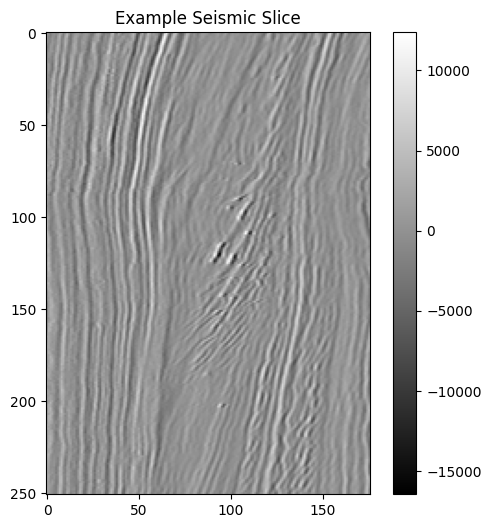

In [4]:
plt.figure(figsize=(6,6))
plt.imshow(cube[100,:,:], cmap="gray")
plt.title("Example Seismic Slice")
plt.colorbar()
plt.show()

In [5]:
save_path = r"E:\Research_Paper\oil_gas_ai\images"
os.makedirs(save_path, exist_ok=True)

print("Image folder ready")

Image folder ready


In [6]:
for i in range(0, cube.shape[0], 5):

    img = cube[i,:,:]

    # Normalize amplitude
    img = (img - img.min()) / (img.max() - img.min())

    filename = os.path.join(save_path, f"inline_{i}.png")

    plt.imsave(filename, img, cmap="gray")

print("All images saved successfully!")

All images saved successfully!


(np.float64(-0.5), np.float64(175.5), np.float64(250.5), np.float64(-0.5))

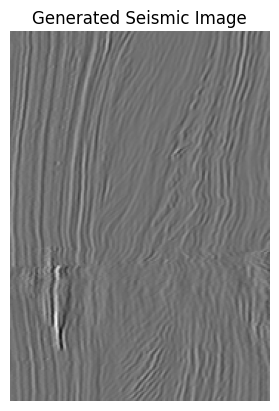

In [7]:
import glob
from PIL import Image

images = glob.glob(save_path + "/*.png")

sample = Image.open(images[0])

plt.imshow(sample, cmap="gray")
plt.title("Generated Seismic Image")
plt.axis("off")

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

In [9]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

In [13]:
import pandas as pd

top = pd.read_csv(
    r"E:\Research_Paper\oil_gas_ai\data\processed\horizons\1-Top.txt",
    comment="#",
    sep=r"\s+",
    header=None
)

base = pd.read_csv(
    r"E:\Research_Paper\oil_gas_ai\data\processed\horizons\2-Base.txt",
    comment="#",
    sep=r"\s+",
    header=None
)

In [14]:
print(top.head())
print(top.columns)

     0    1           2
0  200  700  630.242229
1  200  702  629.372180
2  200  704  628.356874
3  200  706  627.399683
4  200  708  626.880050
Index([0, 1, 2], dtype='int64')


In [15]:
top.columns = ["Inline", "Crossline", "Z"]
base.columns = ["Inline", "Crossline", "Z"]

In [16]:
print(top.head())

   Inline  Crossline           Z
0     200        700  630.242229
1     200        702  629.372180
2     200        704  628.356874
3     200        706  627.399683
4     200        708  626.880050


In [17]:
top["Inline"] = top["Inline"].astype(int)
top["Crossline"] = top["Crossline"].astype(int)

base["Inline"] = base["Inline"].astype(int)
base["Crossline"] = base["Crossline"].astype(int)

In [18]:
top_lookup = {
    (int(row["Inline"]), int(row["Crossline"])): row["Z"]
    for _, row in top.iterrows()
}

base_lookup = {
    (int(row["Inline"]), int(row["Crossline"])): row["Z"]
    for _, row in base.iterrows()
}

In [19]:
print(len(top_lookup))
print(len(base_lookup))

56726
56726


In [20]:
print(list(top_lookup.keys())[:10])

[(200, 700), (200, 702), (200, 704), (200, 706), (200, 708), (200, 710), (200, 712), (200, 714), (200, 716), (200, 718)]


In [21]:
dataset_path = r"E:\Research_Paper\oil_gas_ai\data\features\seismic_data"

reservoir_path = os.path.join(dataset_path, "reservoir")
non_reservoir_path = os.path.join(dataset_path, "non_reservoir")

os.makedirs(reservoir_path, exist_ok=True)
os.makedirs(non_reservoir_path, exist_ok=True)

In [22]:
print(list(top_lookup.keys())[:10])

[(200, 700), (200, 702), (200, 704), (200, 706), (200, 708), (200, 710), (200, 712), (200, 714), (200, 716), (200, 718)]


In [23]:
inline_start = 200
crossline_start = 700

In [24]:
for i in range(0, cube.shape[0], 5):

    slice_img = cube[i,:,:]

    slice_img = (slice_img - slice_img.min())/(slice_img.max()-slice_img.min())

    for j in range(0, cube.shape[1], 2):

        inline = inline_start + i
        crossline = crossline_start + j

        key = (inline, crossline)

        if key in top_lookup and key in base_lookup:

            top_z = top_lookup[key]
            base_z = base_lookup[key]

            thickness = base_z - top_z
            print("Top:", top_z, "Base:", base_z, "Thickness:", thickness)


            if 380 <= thickness <= 395:
                save_dir = reservoir_path
            else:
                save_dir = non_reservoir_path

            filename = f"slice_{inline}_{crossline}.png"
            filepath = os.path.join(save_dir, filename)

            plt.imsave(filepath, slice_img, cmap="gray")

Top: 630.2422285079956 Base: 1034.6134901046753 Thickness: 404.3712615966797
Top: 629.3721795082092 Base: 1033.787488937378 Thickness: 404.4153094291687
Top: 628.3568739891052 Base: 1032.9291820526123 Thickness: 404.5723080635071
Top: 627.3996829986572 Base: 1032.0546627044675 Thickness: 404.6549797058103
Top: 626.8800497055054 Base: 1031.4526557922363 Thickness: 404.57260608673096
Top: 626.579225063324 Base: 1031.0802459716797 Thickness: 404.5010209083557
Top: 626.1895298957825 Base: 1030.7536125183103 Thickness: 404.56408262252785
Top: 625.6408095359801 Base: 1030.5268764495847 Thickness: 404.8860669136046
Top: 625.1024007797241 Base: 1030.4350852966309 Thickness: 405.33268451690674
Top: 624.5912909507751 Base: 1030.3108692169187 Thickness: 405.71957826614357
Top: 624.037504196167 Base: 1030.0031900405884 Thickness: 405.9656858444214
Top: 623.3726143836975 Base: 1029.5767784118652 Thickness: 406.2041640281677
Top: 622.7111220359801 Base: 1029.0746688842771 Thickness: 406.363546848297

In [26]:
import os
import shutil
import random

source_dir = "../data/features/seismic_data"
train_dir = "../data/features/seismic_data/train"
test_dir = "../data/features/seismic_data/test"

classes = ["reservoir", "non_reservoir"]

for c in classes:
    os.makedirs(os.path.join(train_dir, c), exist_ok=True)
    os.makedirs(os.path.join(test_dir, c), exist_ok=True)

    files = os.listdir(os.path.join(source_dir, c))
    random.shuffle(files)

    split = int(0.8 * len(files))

    train_files = files[:split]
    test_files = files[split:]

    for f in train_files:
        shutil.copy(
            os.path.join(source_dir, c, f),
            os.path.join(train_dir, c, f)
        )

    for f in test_files:
        shutil.copy(
            os.path.join(source_dir, c, f),
            os.path.join(test_dir, c, f)
        )

In [27]:
! pip install torch torchvision

In [29]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    "../data/features/seismic_data/train",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    "../data/features/seismic_data/test",
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [46]:
import torch.nn as nn
import torch.nn.functional as F

class SeismicCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.conv3 = nn.Conv2d(32,64,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(64*16*16,128)
        self.fc2 = nn.Linear(128,2)

        self.dropout = nn.Dropout(0.5)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(x.size(0),-1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [55]:
model = SeismicCNN()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

for epoch in range(10):

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:",epoch,"Loss:",loss.item())

Epoch: 0 Loss: 0.6959308981895447
Epoch: 1 Loss: 0.5582585334777832
Epoch: 2 Loss: 0.4676419794559479
Epoch: 3 Loss: 0.5270126461982727
Epoch: 4 Loss: 0.26485925912857056
Epoch: 5 Loss: 0.6485028862953186
Epoch: 6 Loss: 0.5589636564254761
Epoch: 7 Loss: 0.552795946598053
Epoch: 8 Loss: 0.3909461200237274
Epoch: 9 Loss: 0.44634154438972473


In [72]:
from torchvision.models import resnet18

model = resnet18(pretrained=False)

model.conv1 = nn.Conv2d(1,64,7,stride=2,padding=3,bias=False)
model.fc = nn.Linear(512,2)

e:\Research_Paper\oil_gas_ai\myenv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\Research_Paper\oil_gas_ai\myenv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [73]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [74]:
num_epochs = 30

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")

Epoch [1/30]
Train Loss: 0.5373 | Train Accuracy: 75.93%
Epoch [2/30]
Train Loss: 0.4617 | Train Accuracy: 77.26%
Epoch [3/30]
Train Loss: 0.4677 | Train Accuracy: 78.47%
Epoch [4/30]
Train Loss: 0.4549 | Train Accuracy: 78.21%
Epoch [5/30]
Train Loss: 0.4717 | Train Accuracy: 77.31%
Epoch [6/30]
Train Loss: 0.4566 | Train Accuracy: 77.91%
Epoch [7/30]
Train Loss: 0.4517 | Train Accuracy: 78.56%
Epoch [8/30]
Train Loss: 0.4468 | Train Accuracy: 79.47%
Epoch [9/30]
Train Loss: 0.4458 | Train Accuracy: 79.51%
Epoch [10/30]
Train Loss: 0.4561 | Train Accuracy: 78.99%
Epoch [11/30]
Train Loss: 0.4496 | Train Accuracy: 79.08%
Epoch [12/30]
Train Loss: 0.4493 | Train Accuracy: 78.73%
Epoch [13/30]
Train Loss: 0.4437 | Train Accuracy: 78.56%
Epoch [14/30]
Train Loss: 0.4511 | Train Accuracy: 78.52%
Epoch [15/30]
Train Loss: 0.4476 | Train Accuracy: 78.86%
Epoch [16/30]
Train Loss: 0.4613 | Train Accuracy: 77.78%
Epoch [17/30]
Train Loss: 0.4469 | Train Accuracy: 79.42%
Epoch [18/30]
Train Los

In [75]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total

    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print("-----------------------------------")

Test Accuracy: 79.66%
-----------------------------------


In [76]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:", 100 * correct / total)

Accuracy: 79.65517241379311


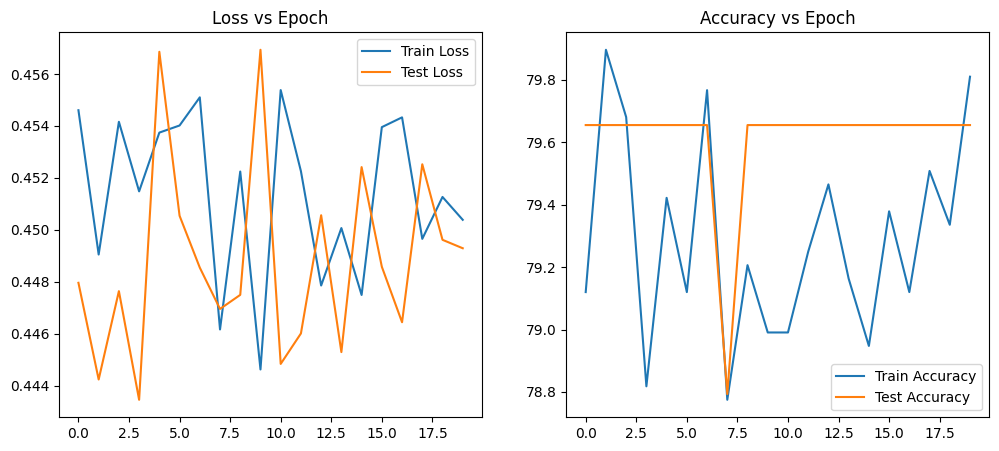

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(train_losses,label="Train Loss")
plt.plot(test_losses,label="Test Loss")
plt.title("Loss vs Epoch")
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(train_acc,label="Train Accuracy")
plt.plot(test_acc,label="Test Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()

plt.show()

In [88]:
import torch

torch.save(model.state_dict(), "../models/seismic_reservoir_cnn.pth")

print("Model saved successfully!")

Model saved successfully!


In [89]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

img = Image.open(r"E:\Research_Paper\oil_gas_ai\data\features\seismic_data\test\reservoir\slice_340_772.png")

img = transform(img).unsqueeze(0)

output = model(img)

_, predicted = torch.max(output,1)

classes = ["non_reservoir","reservoir"]

print("Prediction:", classes[predicted.item()])

Prediction: reservoir


In [90]:
import torch.nn.functional as F

probs = F.softmax(output, dim=1)

print("Non-reservoir probability:", probs[0][0].item())
print("Reservoir probability:", probs[0][1].item())

Non-reservoir probability: 0.373524010181427
Reservoir probability: 0.626475989818573


In [44]:
import os

train_res = len(os.listdir("../data/features/seismic_data/train/reservoir"))
train_non = len(os.listdir("../data/features/seismic_data/train/non_reservoir"))

print("Reservoir:", train_res)
print("Non Reservoir:", train_non)

Reservoir: 1012
Non Reservoir: 1307
